# 🏥 Ejercicio Integrador (8 pts)
## Modulo 2 Tema 2 Transformaciones de Datos para Modelos Predictivos
### Diplomado en Machine Learning para Seguros

Con la base de datos que vieron en el modulo1 y que se encuentra en Github en la carpeta de Modulo 2 llamada **carpeta_q1_2026_final.parquet**, calcular para cada uno de los ramos de accidentes personales y Gastos médicos:


## 1. 📦 Importaciones y Configuración

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import skew, kurtosis, shapiro

from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler, RobustScaler,
    PowerTransformer, LabelEncoder, OneHotEncoder
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Configuración de visualización
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("husl")

pd.set_option('display.max_columns', 55)
SEED=42

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [26]:
# Carga del dataset
DATA_PATH ="./cartera_q1_2026_final.parquet"

df_original = pd.read_parquet(DATA_PATH)

print(f"Dimensiones: {df_original.shape[0]:,} filas × {df_original.shape[1]} columnas")
df_original[:3]

Dimensiones: 50,000 filas × 52 columnas


,id_poliza,num_poliza,nombre,apellido_paterno,apellido_materno,rfc,edad,sexo,estado_civil,ocupacion,ramo,plan,fecha_emision,fecha_inicio_vigencia,fecha_fin_vigencia,num_renovaciones,status_poliza,motivo_baja,canal_venta,marca_vehiculo,modelo_vehiculo,tipo_vehiculo,suma_asegurada,deducible,prima_neta,prima_total,forma_pago,agente_id,estado,municipio,codigo_postal,nombre_agente,region,tipo_agente,comision_pct,n_siniestros,monto_reclamado,monto_pagado,tiene_abierto,tipo_principal,prima_mensual,loss_ratio,comision_est,nivel_riesgo,anio_emision,mes_emision,trimestre,segmento_prima_fijo,cuartil_prima,cod_ramo,anio_poliza,ramo_desde_codigo
0,POL-000001,Vid-21-000001,Gabriela,Moreno,Vega,MOGV020429CG6,24,F,Union libre,Independiente,Vida,10 anios,2021-11-23,2021-11-23,2022-11-23,4,Vigente,NaN,Banca Seguros,NaN,NaN,NaN,3000000,NaN,54000.0,67651.20,Mensual,AG054,Veracruz,Poza Rica,36619.0,Enrique Castillo,Chihuahua,Independiente,0.0871,0.0,0.0,0.0,False,None,5637.600,0.0,5892.41952,BAJO,2021,11,4,Premium,Q4,VID,2021,Vida
1,POL-000002,Aut-19-000002,Valeria,Torres,Castillo,TOVC020815IA8,23,F,Casado,Contador,Autos,Amplia Plus,2019-08-19,2019-08-19,2020-08-19,0,Vigente,NaN,Agente,Hyundai,2024.0,Compacto,150000,8000.0,5250.0,6394.50,Trimestral,AG004,Michoacan,Morelia,58889.0,Patricia Rios,Veracruz,Independiente,0.1380,0.0,0.0,0.0,False,None,532.875,0.0,882.44100,BAJO,2019,8,3,Alta,Q1,AUT,2019,Autos
2,POL-000003,GMM-22-000003,Fernanda,Ramos,Silva,RAFS941018BC1,31,M,Union libre,Ingeniero,GMM,Basico,2022-07-11,2022-07-11,2023-07-11,0,Vigente,NaN,Banca Seguros,NaN,NaN,NaN,800000,5000.0,17600.0,22049.28,Mensual,AG051,Baja California,Tecate,45784.0,Manuel Mendoza,Chihuahua,Independiente,0.0905,0.0,0.0,0.0,False,None,1837.440,0.0,1995.45984,BAJO,2022,7,3,Premium,Q3,GMM,2022,GMM


In [27]:
# Tipos de datos y valores nulos
info = pd.DataFrame({
    'Tipo': df_original.dtypes,
    'Nulos': df_original.isnull().sum(),
    '% Nulos': (df_original.isnull().sum() / len(df_original) * 100).round(2),
    'Únicos': df_original.nunique(),
    'Ejemplo': df_original.iloc[0]
})
print("📋 Resumen del dataset:")
display(info)

📋 Resumen del dataset:


,Tipo,Nulos,% Nulos,Únicos,Ejemplo
id_poliza,object,0,0.00,50000,POL-000001
num_poliza,object,0,0.00,50000,Vid-21-000001
nombre,category,0,0.00,55,Gabriela
apellido_paterno,category,0,0.00,38,Moreno
apellido_materno,category,0,0.00,23,Vega
rfc,object,0,0.00,50000,MOGV020429CG6
edad,int8,0,0.00,46,24
sexo,category,0,0.00,2,F
estado_civil,category,0,0.00,5,Union libre
ocupacion,category,4000,8.00,20,Independiente


In [28]:
# Base de Gastos medicos
df = df_original[df_original.ramo=='GMM'].reset_index(drop=True)

print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df[:3]

Dimensiones: 22,531 filas × 52 columnas


,id_poliza,num_poliza,nombre,apellido_paterno,apellido_materno,rfc,edad,sexo,estado_civil,ocupacion,ramo,plan,fecha_emision,fecha_inicio_vigencia,fecha_fin_vigencia,num_renovaciones,status_poliza,motivo_baja,canal_venta,marca_vehiculo,modelo_vehiculo,tipo_vehiculo,suma_asegurada,deducible,prima_neta,prima_total,forma_pago,agente_id,estado,municipio,codigo_postal,nombre_agente,region,tipo_agente,comision_pct,n_siniestros,monto_reclamado,monto_pagado,tiene_abierto,tipo_principal,prima_mensual,loss_ratio,comision_est,nivel_riesgo,anio_emision,mes_emision,trimestre,segmento_prima_fijo,cuartil_prima,cod_ramo,anio_poliza,ramo_desde_codigo
0,POL-000003,GMM-22-000003,Fernanda,Ramos,Silva,RAFS941018BC1,31,M,Union libre,Ingeniero,GMM,Basico,2022-07-11,2022-07-11,2023-07-11,0,Vigente,NaN,Banca Seguros,NaN,NaN,NaN,800000,5000.0,17600.0,22049.28,Mensual,AG051,Baja California,Tecate,45784.0,Manuel Mendoza,Chihuahua,Independiente,0.0905,0.0,0.0,0.0,False,None,1837.440000,0.0,1995.459840,BAJO,2022,7,3,Premium,Q3,GMM,2022,GMM
1,POL-000007,GMM-23-000007,Mario,Reyes,Castillo,REMC680423LH5,58,M,Divorciado,Jubilado,GMM,Plus,2023-03-05,2023-03-05,2024-03-05,4,Vigente,NaN,Agente,NaN,NaN,NaN,1000000,8000.0,27940.0,32410.40,Anual,AG024,Chihuahua,Chihuahua,19235.0,Luis Salazar,CDMX,Empresa,0.0690,0.0,0.0,0.0,False,None,2700.866667,0.0,2236.317600,BAJO,2023,3,1,Premium,Q3,GMM,2023,GMM
2,POL-000008,GMM-19-000008,Carlos,Rivera,Sanchez,RICS710805YY4,54,M,Casado,Director,GMM,Plus,2019-03-23,2019-03-23,2020-03-23,2,Vigente,NaN,Directo,NaN,NaN,NaN,200000,10000.0,5324.0,6484.63,Trimestral,AG013,Nuevo Leon,Apodaca,35661.0,Luz Medina,Michoacan,Independiente,0.0971,0.0,0.0,0.0,False,None,540.385833,0.0,629.657573,BAJO,2019,3,1,Alta,Q1,GMM,2019,GMM


In [ ]:
# Base de Gastos medicos
df_ap = df_original[df_original.ramo=='Accidentes Personales'].reset_index(drop=True)

print(f"Dimensiones: {df_ap.shape[0]:,} filas × {df_ap.shape[1]} columnas")
df_ap[:3]

Dimensiones: 5,207 filas × 52 columnas


,id_poliza,num_poliza,nombre,apellido_paterno,apellido_materno,rfc,edad,sexo,estado_civil,ocupacion,ramo,plan,fecha_emision,fecha_inicio_vigencia,fecha_fin_vigencia,num_renovaciones,status_poliza,motivo_baja,canal_venta,marca_vehiculo,modelo_vehiculo,tipo_vehiculo,suma_asegurada,deducible,prima_neta,prima_total,forma_pago,agente_id,estado,municipio,codigo_postal,nombre_agente,region,tipo_agente,comision_pct,n_siniestros,monto_reclamado,monto_pagado,tiene_abierto,tipo_principal,prima_mensual,loss_ratio,comision_est,nivel_riesgo,anio_emision,mes_emision,trimestre,segmento_prima_fijo,cuartil_prima,cod_ramo,anio_poliza,ramo_desde_codigo
0,POL-000016,Acc-22-000016,Francisco,Hernandez,Flores,HEFF600914YS7,65,F,Union libre,Estudiante,Accidentes Personales,Familiar,2022-03-15,2022-03-15,2023-03-15,1,Vigente,NaN,Agente,NaN,NaN,NaN,300000,3000.0,3600.0,4301.28,Semestral,AG032,Queretaro,San Juan del Rio,64252.0,Norma Medina,Yucatan,Empresa,0.0645,0.0,0.0,0.0,False,None,358.44,0.0,277.43256,BAJO,2022,3,1,Media,Q1,ACC,2022,Accidentes Personales
1,POL-000021,Acc-20-000021,Valeria,Flores,Cruz,FLVC970522FF7,28,M,Viudo,Tecnico,Accidentes Personales,Individual,2020-04-27,2020-04-27,2021-04-27,0,Vigente,NaN,Agente,NaN,NaN,NaN,500000,3000.0,6000.0,7516.80,Mensual,AG035,CDMX,Coyoacan,83825.0,Lorena Ramos,Estado de Mexico,Independiente,0.0925,0.0,0.0,0.0,False,None,626.40,0.0,695.30400,BAJO,2020,4,2,Alta,Q1,ACC,2020,Accidentes Personales
2,POL-000034,Acc-22-000034,Oscar,Morales,Garcia,MOOG850901YF9,40,F,Viudo,Tecnico,Accidentes Personales,Familiar,2022-04-07,2022-04-07,2023-04-07,2,Vigente,NaN,Banca Seguros,NaN,NaN,NaN,300000,2000.0,3600.0,4384.80,Trimestral,AG040,Jalisco,Tonala,77797.0,Luz Rodriguez,Tamaulipas,Independiente,0.0894,0.0,0.0,0.0,False,None,365.40,0.0,392.00112,BAJO,2022,4,2,Media,Q1,ACC,2022,Accidentes Personales


## 1. Calcular estadísticas descriptivas (número de pólizas, prima total, prima promedio, número de siniestros, siniestro promedio, etc.)

### Gastos Médicos

In [29]:
# Estadísticas descriptivas de variables numéricas
print("📊 Estadísticas descriptivas:")
display(df.describe().round(2))

📊 Estadísticas descriptivas:


,edad,fecha_emision,fecha_inicio_vigencia,fecha_fin_vigencia,num_renovaciones,modelo_vehiculo,suma_asegurada,deducible,prima_neta,prima_total,codigo_postal,comision_pct,n_siniestros,monto_reclamado,monto_pagado,prima_mensual,loss_ratio,comision_est,anio_emision,mes_emision,trimestre,anio_poliza
count,22531.00,22531,22531,22531,22531.00,0.0,22531.00,22531.00,22531.00,22531.00,21841.00,22531.00,22531.00,22531.00,22531.00,22531.00,22531.0,22531.00,22531.00,22531.00,22531.00,22531.0
mean,43.30,2021-12-29 16:03:43.691802624,2021-12-29 16:03:43.691802624,2022-12-30 00:04:01.587146752,1.24,NaN,1106999.25,11623.54,26882.93,32445.18,54918.89,0.11,0.36,13403.79,4301.29,2703.76,0.2,3486.62,2021.50,6.52,2.51,2021.5
min,21.00,2019-01-01 00:00:00,2019-01-01 00:00:00,2020-01-01 00:00:00,0.00,NaN,200000.00,5000.00,4400.00,5104.00,10009.00,0.06,0.00,0.00,0.00,425.33,0.0,309.81,2019.00,1.00,1.00,2019.0
25%,32.00,2020-06-23 00:00:00,2020-06-23 00:00:00,2021-06-23 00:00:00,0.00,NaN,300000.00,8000.00,8085.00,9493.44,32049.00,0.09,0.00,0.00,0.00,791.12,0.0,1023.00,2020.00,4.00,2.00,2020.0
50%,43.00,2021-12-29 00:00:00,2021-12-29 00:00:00,2022-12-29 00:00:00,1.00,NaN,800000.00,10000.00,17864.00,22049.28,54962.00,0.11,0.00,0.00,0.00,1837.44,0.0,2210.44,2021.00,7.00,3.00,2021.0
75%,54.00,2023-06-28 00:00:00,2023-06-28 00:00:00,2024-06-28 00:00:00,2.00,NaN,2000000.00,15000.00,44000.00,52571.20,77514.00,0.13,1.00,10300.81,0.00,4380.93,0.0,4928.01,2023.00,10.00,4.00,2023.0
max,66.00,2024-12-29 00:00:00,2024-12-29 00:00:00,2025-12-29 00:00:00,4.00,NaN,3000000.00,20000.00,91740.00,114931.87,99998.00,0.15,4.00,947321.62,698744.32,9577.66,5.0,16837.52,2024.00,12.00,4.00,2024.0
std,12.97,NaN,NaN,NaN,1.13,NaN,951412.30,5319.32,23439.30,28387.43,26091.53,0.03,0.60,37203.45,20609.64,2365.62,0.8,3261.47,1.71,3.45,1.12,1.71


In [30]:
bins_edad = [17, 25, 35, 45, 55, 65]
labels_edad = ['18-25', '26-35', '36-45', '46-55', '56-64']

df['grupo_edad'] = pd.cut(df['edad'], bins=bins_edad, labels=labels_edad)

### Accidentes Personales

In [76]:
# Estadísticas descriptivas de variables numéricas
print("📊 Estadísticas descriptivas:")
display(df_ap.describe().round(2))

📊 Estadísticas descriptivas:


,edad,fecha_emision,fecha_inicio_vigencia,fecha_fin_vigencia,num_renovaciones,modelo_vehiculo,suma_asegurada,deducible,prima_neta,prima_total,codigo_postal,comision_pct,n_siniestros,monto_reclamado,monto_pagado,prima_mensual,loss_ratio,comision_est,anio_emision,mes_emision,trimestre,anio_poliza
count,5207.00,5207,5207,5207,5207.00,0.0,5207.00,5207.00,5207.00,5207.00,5059.00,5207.00,5207.00,5207.00,5207.00,5207.00,5207.00,5207.00,5207.00,5207.00,5207.00,5207.0
mean,43.49,2022-01-16 09:12:16.316496896,2022-01-16 09:12:16.316496896,2023-01-16 17:10:58.882274048,1.23,NaN,333397.35,2006.53,3995.01,4797.52,54507.51,0.11,0.35,12990.09,4284.89,399.79,0.41,515.28,2021.55,6.49,2.50,2021.55
min,21.00,2019-01-01 00:00:00,2019-01-01 00:00:00,2020-01-01 00:00:00,0.00,NaN,200000.00,1000.00,2400.00,2784.00,10000.00,0.06,0.00,0.00,0.00,232.00,0.00,168.99,2019.00,1.00,1.00,2019.0
25%,32.00,2020-07-10 00:00:00,2020-07-10 00:00:00,2021-07-10 00:00:00,0.00,NaN,200000.00,1000.00,2400.00,3006.72,31653.00,0.09,0.00,0.00,0.00,250.56,0.00,331.02,2020.00,4.00,2.00,2020.0
50%,44.00,2022-01-18 00:00:00,2022-01-18 00:00:00,2023-01-18 00:00:00,1.00,NaN,300000.00,2000.00,3600.00,4301.28,54525.00,0.11,0.00,0.00,0.00,358.44,0.00,461.87,2022.00,6.00,2.00,2022.0
75%,54.00,2023-08-14 12:00:00,2023-08-14 12:00:00,2024-08-14 12:00:00,2.00,NaN,500000.00,3000.00,6000.00,6960.00,76917.50,0.13,1.00,8442.94,0.00,580.00,0.00,645.84,2023.00,9.00,3.00,2023.0
max,66.00,2024-12-29 00:00:00,2024-12-29 00:00:00,2025-12-29 00:00:00,4.00,NaN,500000.00,3000.00,6000.00,7516.80,99938.00,0.15,4.00,1224593.15,1067933.83,626.40,5.00,1125.26,2024.00,12.00,4.00,2024.0
std,12.79,NaN,NaN,NaN,1.14,NaN,125121.69,821.79,1489.77,1804.03,26069.13,0.03,0.59,40593.26,25761.29,150.34,1.27,236.97,1.72,3.44,1.12,1.72


In [77]:
bins_edad = [17, 25, 35, 45, 55, 65]
labels_edad = ['18-25', '26-35', '36-45', '46-55', '56-64']

df_ap['grupo_edad'] = pd.cut(df_ap['edad'], bins=bins_edad, labels=labels_edad)

## 2.	Obtener los histogramas de las variables: sexo, edad, año de inicio de vigencia, plan, primas y siniestros. ¿Qué observas?

### Gastos Medicos

In [31]:
df['anio_ini_vig'] = df.fecha_inicio_vigencia.dt.year

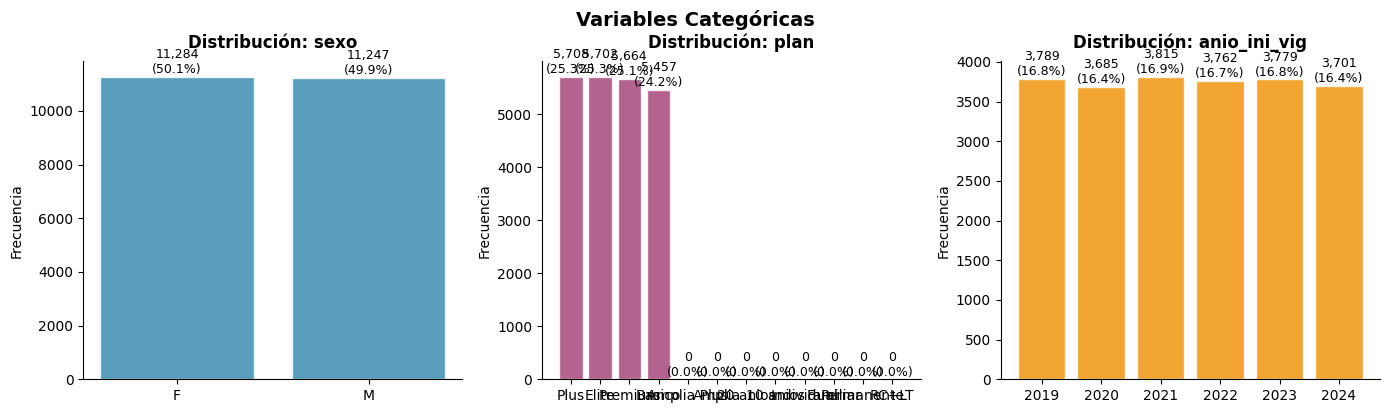

In [32]:
# Distribución de variables categóricas
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

categoricas = ['sexo', 'plan', 'anio_ini_vig']
colores = ['#2E86AB', '#A23B72', '#F18F01']

for ax, col, color in zip(axes, categoricas, colores):
    counts = df[col].value_counts()
    bars = ax.bar(counts.index, counts.values, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'Distribución: {col}', fontweight='bold', pad=10)
    ax.set_ylabel('Frecuencia')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.suptitle('Variables Categóricas', fontsize=14, fontweight='bold', y=1.02)
plt.show()

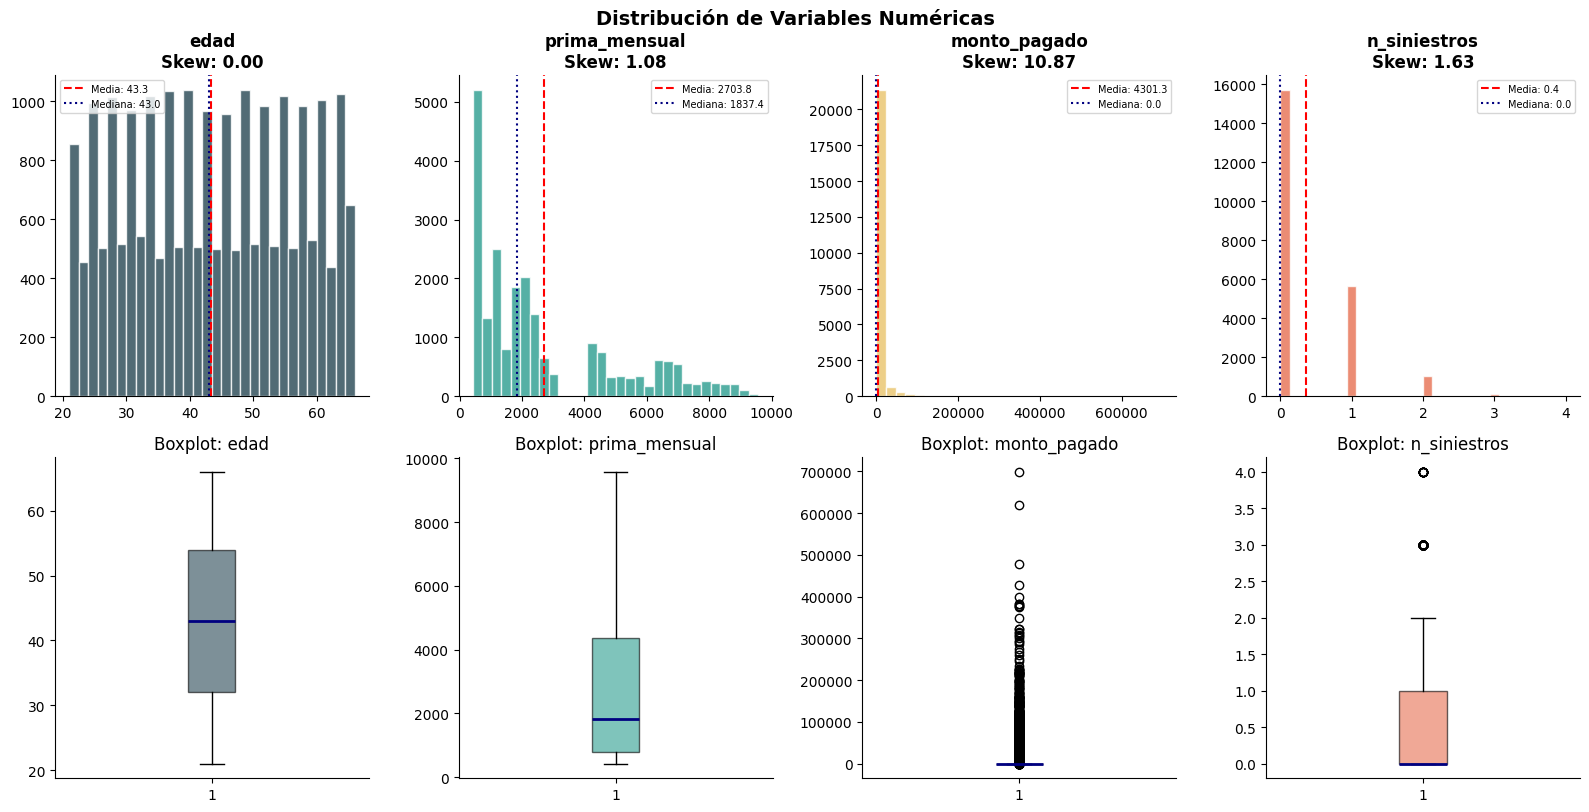


📌 Observaciones clave:
  • Siniestro: sesgo = 10.871 → distribución muy sesgada a la derecha
  • Prima:     sesgo = 1.078 → distribución cercana a normal
  • Edad:     sesgo = 0.003 → distribución relativamente simétrica
  • Num Siniestros:     sesgo = 1.629 → distribución relativamente simétrica


In [33]:
# Distribución de variables numéricas + variable objetivo
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
vars_num = ['edad', 'prima_mensual', 'monto_pagado','n_siniestros']
colores2 = ['#264653', '#2A9D8F', '#E9C46A', '#E76F51']

for i, (var, color) in enumerate(zip(vars_num, colores2)):
    # Histograma
    ax_hist = axes[0, i]
    ax_hist.hist(df[var], bins=30, color=color, alpha=0.8, edgecolor='white')
    ax_hist.axvline(df[var].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Media: {df[var].mean():.1f}')
    ax_hist.axvline(df[var].median(), color='navy', linestyle=':', linewidth=1.5, label=f'Mediana: {df[var].median():.1f}')
    ax_hist.set_title(f'{var}\nSkew: {skew(df[var]):.2f}', fontweight='bold')
    ax_hist.legend(fontsize=7)

    # Boxplot
    ax_box = axes[1, i]
    ax_box.boxplot(df[var], vert=True, patch_artist=True,
                   boxprops=dict(facecolor=color, alpha=0.6),
                   medianprops=dict(color='navy', linewidth=2))
    ax_box.set_title(f'Boxplot: {var}')

plt.tight_layout()
plt.suptitle('Distribución de Variables Numéricas', fontsize=14, fontweight='bold', y=1.01)
plt.show()

print("\n📌 Observaciones clave:")
print(f"  • Siniestro: sesgo = {skew(df.monto_pagado):.3f} → distribución muy sesgada a la derecha")
print(f"  • Prima:     sesgo = {skew(df.prima_mensual):.3f} → distribución cercana a normal")
print(f"  • Edad:     sesgo = {skew(df.edad):.3f} → distribución relativamente simétrica")
print(f"  • Num Siniestros:     sesgo = {skew(df.n_siniestros):.3f} → distribución relativamente simétrica")

### Accidentes Personales

In [78]:
df_ap['anio_ini_vig'] = df_ap.fecha_inicio_vigencia.dt.year

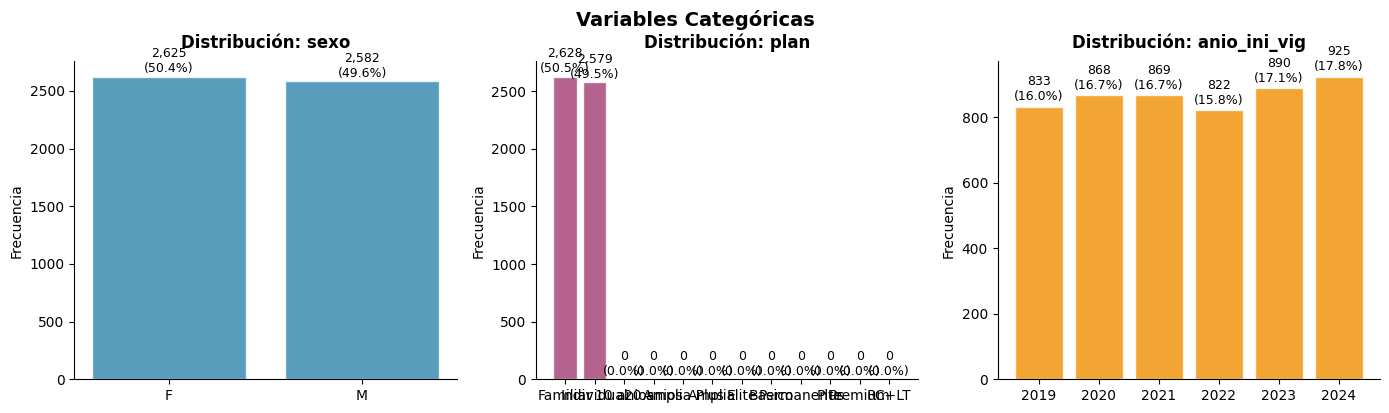

In [79]:
# Distribución de variables categóricas
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

categoricas = ['sexo', 'plan', 'anio_ini_vig']
colores = ['#2E86AB', '#A23B72', '#F18F01']

for ax, col, color in zip(axes, categoricas, colores):
    counts = df_ap[col].value_counts()
    bars = ax.bar(counts.index, counts.values, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'Distribución: {col}', fontweight='bold', pad=10)
    ax.set_ylabel('Frecuencia')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{val:,}\n({val/len(df_ap)*100:.1f}%)', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.suptitle('Variables Categóricas', fontsize=14, fontweight='bold', y=1.02)
plt.show()

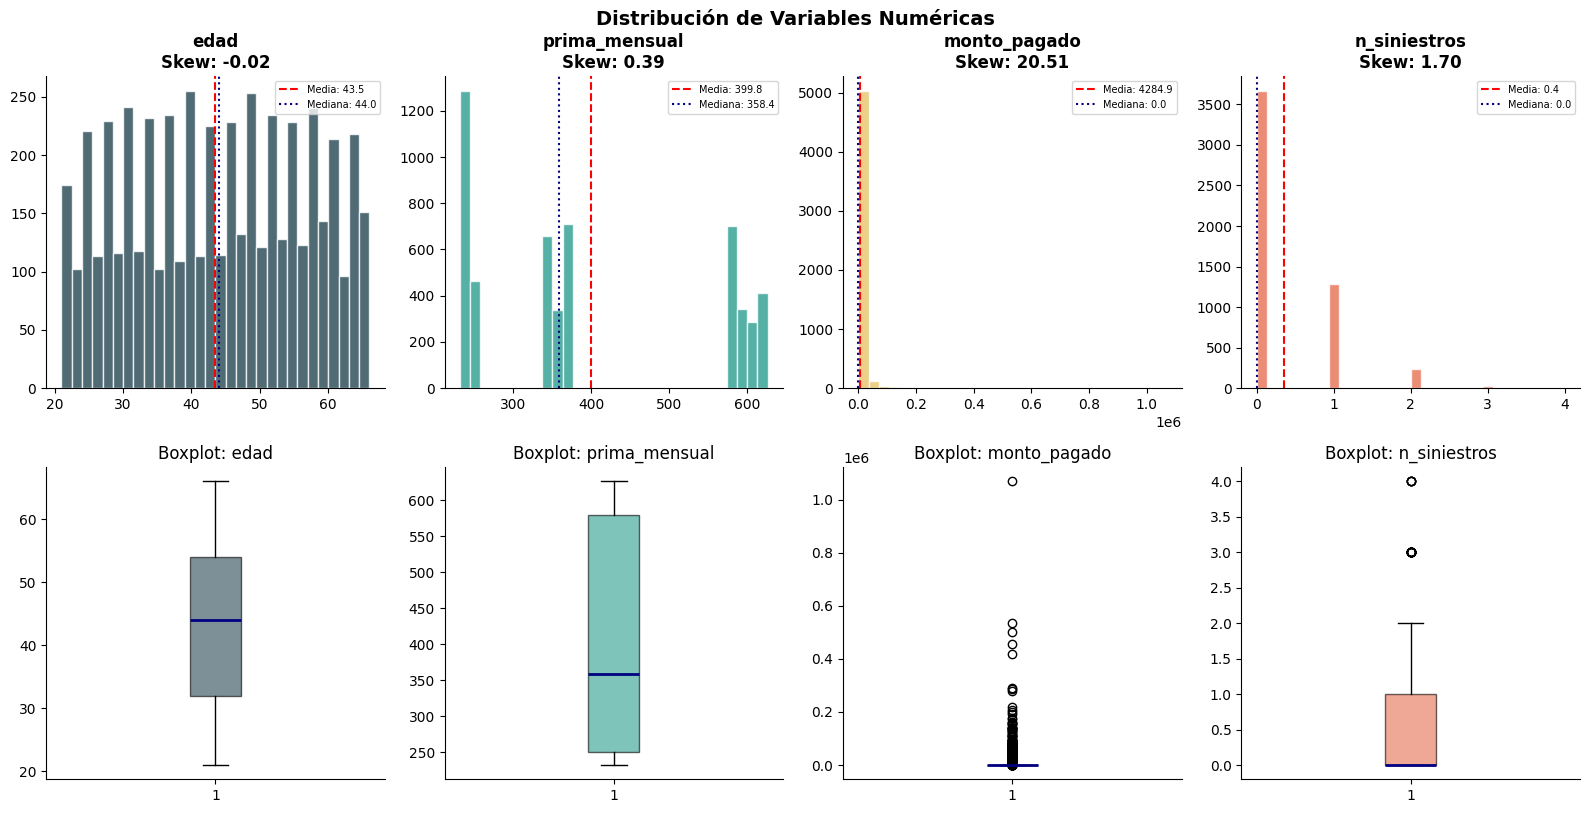


📌 Observaciones clave:
  • Siniestro: sesgo = 20.510 → distribución muy sesgada a la derecha
  • Prima:     sesgo = 0.388 → distribución cercana a normal
  • Edad:     sesgo = -0.020 → distribución relativamente simétrica
  • Num Siniestros:     sesgo = 1.695 → distribución relativamente simétrica


In [81]:
# Distribución de variables numéricas + variable objetivo
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
vars_num = ['edad', 'prima_mensual', 'monto_pagado','n_siniestros']
colores2 = ['#264653', '#2A9D8F', '#E9C46A', '#E76F51']

for i, (var, color) in enumerate(zip(vars_num, colores2)):
    # Histograma
    ax_hist = axes[0, i]
    ax_hist.hist(df_ap[var], bins=30, color=color, alpha=0.8, edgecolor='white')
    ax_hist.axvline(df_ap[var].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Media: {df_ap[var].mean():.1f}')
    ax_hist.axvline(df_ap[var].median(), color='navy', linestyle=':', linewidth=1.5, label=f'Mediana: {df_ap[var].median():.1f}')
    ax_hist.set_title(f'{var}\nSkew: {skew(df_ap[var]):.2f}', fontweight='bold')
    ax_hist.legend(fontsize=7)

    # Boxplot
    ax_box = axes[1, i]
    ax_box.boxplot(df_ap[var], vert=True, patch_artist=True,
                   boxprops=dict(facecolor=color, alpha=0.6),
                   medianprops=dict(color='navy', linewidth=2))
    ax_box.set_title(f'Boxplot: {var}')

plt.tight_layout()
plt.suptitle('Distribución de Variables Numéricas', fontsize=14, fontweight='bold', y=1.01)
plt.show()

print("\n📌 Observaciones clave:")
print(f"  • Siniestro: sesgo = {skew(df_ap.monto_pagado):.3f} → distribución muy sesgada a la derecha")
print(f"  • Prima:     sesgo = {skew(df_ap.prima_mensual):.3f} → distribución cercana a normal")
print(f"  • Edad:     sesgo = {skew(df_ap.edad):.3f} → distribución relativamente simétrica")
print(f"  • Num Siniestros:     sesgo = {skew(df_ap.n_siniestros):.3f} → distribución relativamente simétrica")

---
## 4. ⚖️ Aplicar los 3 tipos de escalamiento a primas y siniestros. Obtén sus estadísticas y compáralas con las originales. ¿Qué concluyes?

### Tres técnicas a comparar:

| Técnica | Fórmula | Rango resultado | Cuándo usar |
|---------|---------|-----------------|-------------|
| **Min-Max** | (x - min) / (max - min) | [0, 1] | Variables acotadas, sin outliers extremos |
| **Z-Score** | (x - μ) / σ | (-∞, +∞) | Variables aproximadamente normales |
| **Robust Scaler** | (x - Q2) / (Q3 - Q1) | Variable | Variables con outliers (como `charges`) |


### Gastos Medicos

In [34]:
# Split train/test ANTES de cualquier transformación
# ⚠️ Regla de oro: ajustar solo en train, transformar en test

vars_numericas = ['monto_pagado', 'prima_mensual']

X = df[vars_numericas]
y = df['monto_pagado']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

print(f"✅ Split completado:")
print(f"   Train: {X_train.shape[0]:,} filas ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Test:  {X_test.shape[0]:,} filas ({X_test.shape[0]/len(X)*100:.0f}%)")

✅ Split completado:
   Train: 18,024 filas (80%)
   Test:  4,507 filas (20%)


In [35]:
# Aplicar los tres scalers — ajuste SOLO en train
scalers = {
    'Min-Max Scaler':   MinMaxScaler(),
    'Z-Score (Standard)': StandardScaler(),
    'Robust Scaler':    RobustScaler()
}

resultados_scaling = {}
for nombre, scaler in scalers.items():
    X_train_sc = scaler.fit_transform(X_train)          # fit + transform en train
    X_test_sc  = scaler.transform(X_test)               # solo transform en test
    resultados_scaling[nombre] = {
        'train': pd.DataFrame(X_train_sc, columns=vars_numericas),
        'test':  pd.DataFrame(X_test_sc, columns=vars_numericas)
    }
    print(f"✅ {nombre} ajustado y aplicado")

print("\n🎯 Recuerda: el scaler se ajusta UNA sola vez (en train) y se aplica N veces (train, test, producción)")

✅ Min-Max Scaler ajustado y aplicado
✅ Z-Score (Standard) ajustado y aplicado
✅ Robust Scaler ajustado y aplicado

🎯 Recuerda: el scaler se ajusta UNA sola vez (en train) y se aplica N veces (train, test, producción)


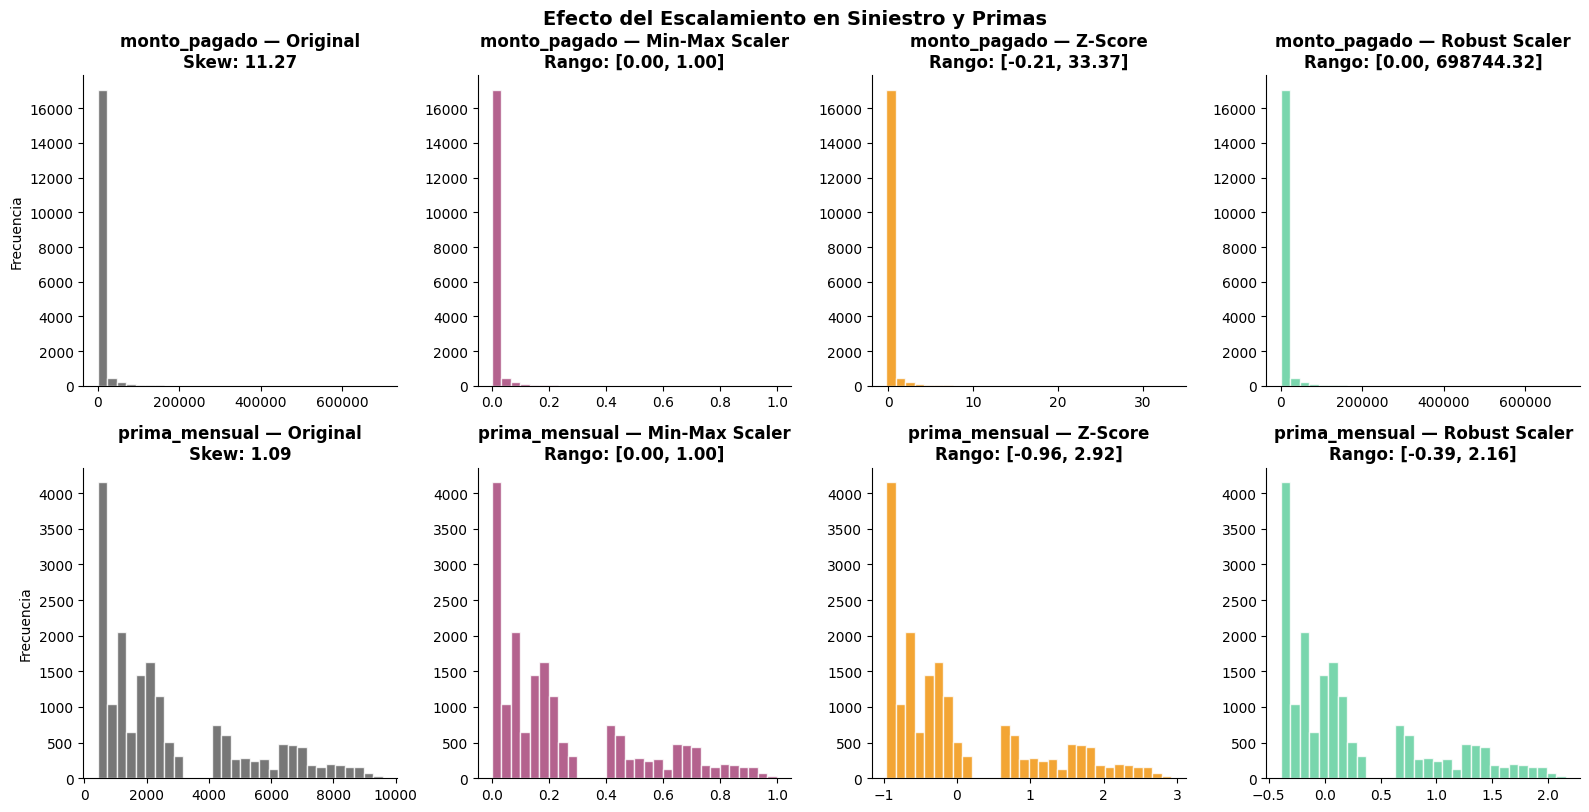

In [36]:
# Visualización comparativa: efecto del escalamiento en charges y bmi
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
vars_plot = ['monto_pagado', 'prima_mensual']
colores_sc = ['#2E86AB', '#A23B72', '#F18F01', '#57CC99']

for row, var in enumerate(vars_plot):
    # Original
    axes[row, 0].hist(X_train[var], bins=30, color='#555555', alpha=0.8, edgecolor='white')
    axes[row, 0].set_title(f'{var} — Original\nSkew: {skew(X_train[var]):.2f}', fontweight='bold')
    axes[row, 0].set_ylabel('Frecuencia')

    for col, (nombre, data) in enumerate(resultados_scaling.items(), start=1):
        series = data['train'][var]
        axes[row, col].hist(series, bins=30, color=colores_sc[col], alpha=0.8, edgecolor='white')
        short_name = nombre.split('(')[0].strip()
        axes[row, col].set_title(f'{var} — {short_name}\nRango: [{series.min():.2f}, {series.max():.2f}]', fontweight='bold')

plt.tight_layout()
plt.suptitle('Efecto del Escalamiento en Siniestro y Primas', fontsize=14, fontweight='bold', y=1.01)
plt.show()

In [37]:
# Tabla resumen: estadísticas después del escalamiento
print("=" * 70)
print("TABLA COMPARATIVA: monto pagado después de escalar")
print("=" * 70)
print(f"{'Método':<25} {'Media':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-" * 70)
print(f"{'Original':<25} {X_train.monto_pagado.mean():>10.2f} {X_train.monto_pagado.std():>10.2f} {X_train.monto_pagado.min():>10.2f} {X_train.monto_pagado.max():>10.2f}")
for nombre, data in resultados_scaling.items():
    s = data['train']['monto_pagado']
    print(f"{nombre:<25} {s.mean():>10.4f} {s.std():>10.4f} {s.min():>10.4f} {s.max():>10.4f}")

print("\n💡 Conclusión actuarial:")
print("   • Min-Max: Se visualiza de mejor manera ya que no arroja valores negativos, por lo que " \
"su interpretación es más sencilla ")

TABLA COMPARATIVA: monto pagado después de escalar
Método                         Media        Std        Min        Max
----------------------------------------------------------------------
Original                     4305.64   20812.38       0.00  698744.32
Min-Max Scaler                0.0062     0.0298     0.0000     1.0000
Z-Score (Standard)           -0.0000     1.0000    -0.2069    33.3675
Robust Scaler              4305.6379 20812.3766     0.0000 698744.3200

💡 Conclusión actuarial:
   • Min-Max: Se visualiza de mejor manera ya que no arroja valores negativos, por lo que su interpretación es más sencilla 


In [38]:
# Tabla resumen: estadísticas después del escalamiento
print("=" * 70)
print("TABLA COMPARATIVA: prima después de escalar")
print("=" * 70)
print(f"{'Método':<25} {'Media':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-" * 70)
print(f"{'Original':<25} {X_train.prima_mensual.mean():>10.2f} {X_train.prima_mensual.std():>10.2f} {X_train.prima_mensual.min():>10.2f} {X_train.prima_mensual.max():>10.2f}")
for nombre, data in resultados_scaling.items():
    s = data['train']['prima_mensual']
    print(f"{nombre:<25} {s.mean():>10.4f} {s.std():>10.4f} {s.min():>10.4f} {s.max():>10.4f}")

print("\n💡 Conclusión actuarial:")
print("   • Min-Max: Se visualiza de mejor manera ya que no arroja valores negativos, por lo que " \
"su interpretación es más sencilla ")

TABLA COMPARATIVA: prima después de escalar
Método                         Media        Std        Min        Max
----------------------------------------------------------------------
Original                     2694.32    2355.13     425.33    9577.66
Min-Max Scaler                0.2479     0.2573     0.0000     1.0000
Z-Score (Standard)           -0.0000     1.0000    -0.9634     2.9228
Robust Scaler                 0.2387     0.6561    -0.3934     2.1562

💡 Conclusión actuarial:
   • Min-Max: Se visualiza de mejor manera ya que no arroja valores negativos, por lo que su interpretación es más sencilla 


### Accidentes Personales

In [82]:
# Split train/test ANTES de cualquier transformación
# ⚠️ Regla de oro: ajustar solo en train, transformar en test

vars_numericas = ['monto_pagado', 'prima_mensual']

X = df_ap[vars_numericas]
y = df_ap['monto_pagado']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

print(f"✅ Split completado:")
print(f"   Train: {X_train.shape[0]:,} filas ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Test:  {X_test.shape[0]:,} filas ({X_test.shape[0]/len(X)*100:.0f}%)")

✅ Split completado:
   Train: 4,165 filas (80%)
   Test:  1,042 filas (20%)


In [83]:
# Aplicar los tres scalers — ajuste SOLO en train
scalers = {
    'Min-Max Scaler':   MinMaxScaler(),
    'Z-Score (Standard)': StandardScaler(),
    'Robust Scaler':    RobustScaler()
}

resultados_scaling = {}
for nombre, scaler in scalers.items():
    X_train_sc = scaler.fit_transform(X_train)          # fit + transform en train
    X_test_sc  = scaler.transform(X_test)               # solo transform en test
    resultados_scaling[nombre] = {
        'train': pd.DataFrame(X_train_sc, columns=vars_numericas),
        'test':  pd.DataFrame(X_test_sc, columns=vars_numericas)
    }
    print(f"✅ {nombre} ajustado y aplicado")

print("\n🎯 Recuerda: el scaler se ajusta UNA sola vez (en train) y se aplica N veces (train, test, producción)")

✅ Min-Max Scaler ajustado y aplicado
✅ Z-Score (Standard) ajustado y aplicado
✅ Robust Scaler ajustado y aplicado

🎯 Recuerda: el scaler se ajusta UNA sola vez (en train) y se aplica N veces (train, test, producción)


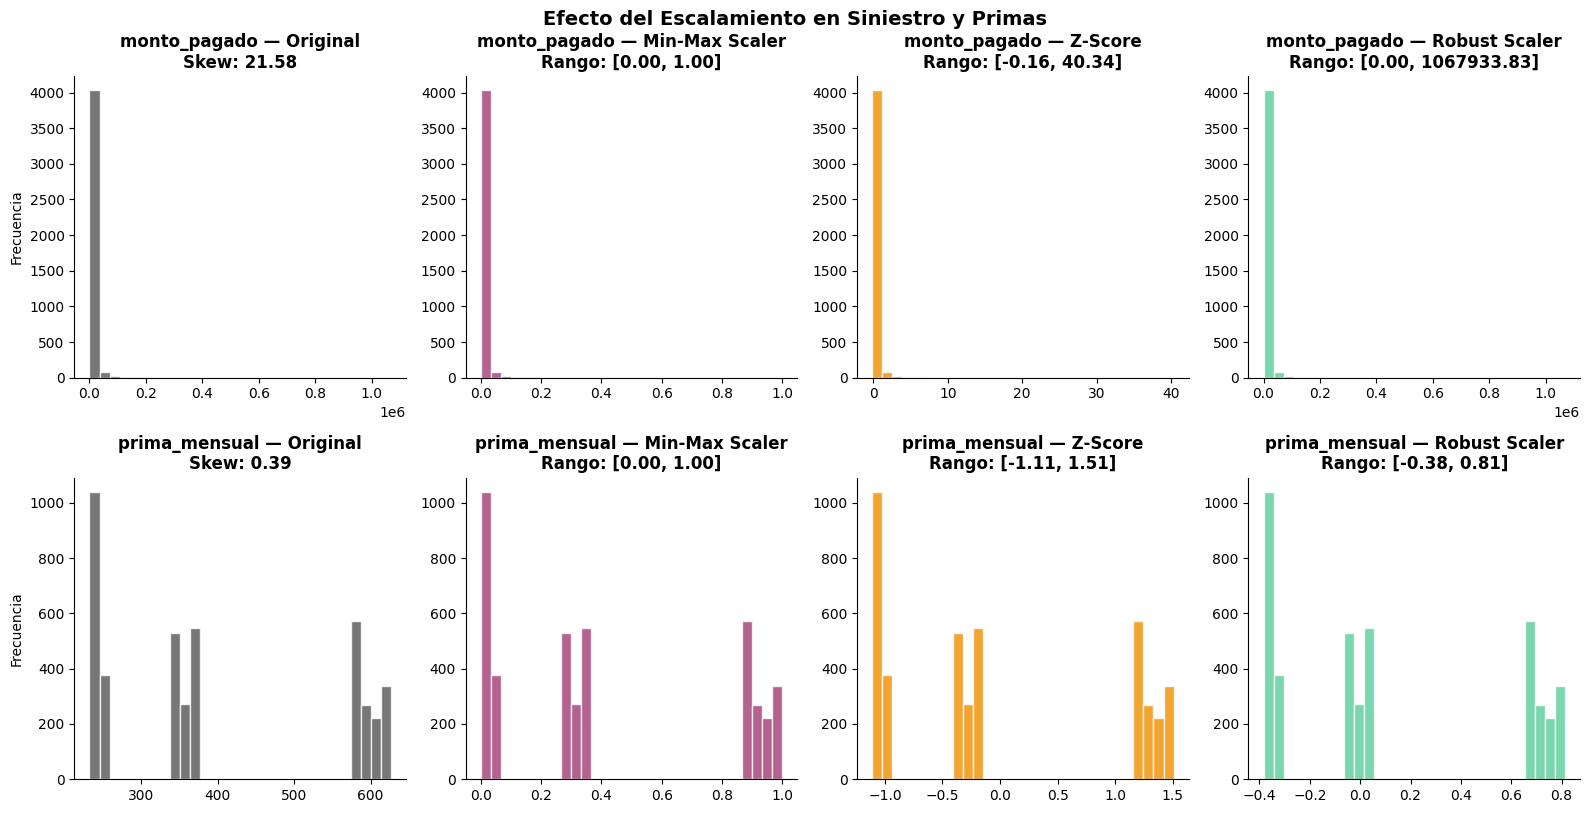

In [84]:
# Visualización comparativa: efecto del escalamiento en charges y bmi
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
vars_plot = ['monto_pagado', 'prima_mensual']
colores_sc = ['#2E86AB', '#A23B72', '#F18F01', '#57CC99']

for row, var in enumerate(vars_plot):
    # Original
    axes[row, 0].hist(X_train[var], bins=30, color='#555555', alpha=0.8, edgecolor='white')
    axes[row, 0].set_title(f'{var} — Original\nSkew: {skew(X_train[var]):.2f}', fontweight='bold')
    axes[row, 0].set_ylabel('Frecuencia')

    for col, (nombre, data) in enumerate(resultados_scaling.items(), start=1):
        series = data['train'][var]
        axes[row, col].hist(series, bins=30, color=colores_sc[col], alpha=0.8, edgecolor='white')
        short_name = nombre.split('(')[0].strip()
        axes[row, col].set_title(f'{var} — {short_name}\nRango: [{series.min():.2f}, {series.max():.2f}]', fontweight='bold')

plt.tight_layout()
plt.suptitle('Efecto del Escalamiento en Siniestro y Primas', fontsize=14, fontweight='bold', y=1.01)
plt.show()

In [85]:
# Tabla resumen: estadísticas después del escalamiento
print("=" * 70)
print("TABLA COMPARATIVA: monto pagado después de escalar")
print("=" * 70)
print(f"{'Método':<25} {'Media':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-" * 70)
print(f"{'Original':<25} {X_train.monto_pagado.mean():>10.2f} {X_train.monto_pagado.std():>10.2f} {X_train.monto_pagado.min():>10.2f} {X_train.monto_pagado.max():>10.2f}")
for nombre, data in resultados_scaling.items():
    s = data['train']['monto_pagado']
    print(f"{nombre:<25} {s.mean():>10.4f} {s.std():>10.4f} {s.min():>10.4f} {s.max():>10.4f}")

print("\n💡 Conclusión actuarial:")
print("   • Min-Max: Se visualiza de mejor manera ya que no arroja valores negativos, por lo que " \
"su interpretación es más sencilla ")

TABLA COMPARATIVA: monto pagado después de escalar
Método                         Media        Std        Min        Max
----------------------------------------------------------------------
Original                     4204.98   26375.25       0.00 1067933.83
Min-Max Scaler                0.0039     0.0247     0.0000     1.0000
Z-Score (Standard)           -0.0000     1.0001    -0.1594    40.3354
Robust Scaler              4204.9779 26375.2466     0.0000 1067933.8300

💡 Conclusión actuarial:
   • Min-Max: Se visualiza de mejor manera ya que no arroja valores negativos, por lo que su interpretación es más sencilla 


In [86]:
# Tabla resumen: estadísticas después del escalamiento
print("=" * 70)
print("TABLA COMPARATIVA: prima después de escalar")
print("=" * 70)
print(f"{'Método':<25} {'Media':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-" * 70)
print(f"{'Original':<25} {X_train.prima_mensual.mean():>10.2f} {X_train.prima_mensual.std():>10.2f} {X_train.prima_mensual.min():>10.2f} {X_train.prima_mensual.max():>10.2f}")
for nombre, data in resultados_scaling.items():
    s = data['train']['prima_mensual']
    print(f"{nombre:<25} {s.mean():>10.4f} {s.std():>10.4f} {s.min():>10.4f} {s.max():>10.4f}")

print("\n💡 Conclusión actuarial:")
print("   • Min-Max: Se visualiza de mejor manera ya que no arroja valores negativos, por lo que " \
"su interpretación es más sencilla ")

TABLA COMPARATIVA: prima después de escalar
Método                         Media        Std        Min        Max
----------------------------------------------------------------------
Original                      399.34     150.69     232.00     626.40
Min-Max Scaler                0.4243     0.3821     0.0000     1.0000
Z-Score (Standard)           -0.0000     1.0001    -1.1106     1.5070
Robust Scaler                 0.1241     0.4574    -0.3838     0.8134

💡 Conclusión actuarial:
   • Min-Max: Se visualiza de mejor manera ya que no arroja valores negativos, por lo que su interpretación es más sencilla 


---
## 5.	Haz la transformación Box-Cox, logarítmica y Yeo-Johnson al monto del siniestro. Haz un histograma de la serie original y cada una de las transformaciones. Agrega la distribución normal.

## 6.	Crea el Q-Q plot para la serie original y cada transformación, haz la prueba de hipótesis de normalidad. ¿Qué concluyes?


### Gastos Médicos

In [52]:
siniestro = df[df.monto_pagado>0]['monto_pagado'].copy()

# 1. Transformación Logarítmica
charges_log = np.log(siniestro+1)

# 2. Box-Cox (solo valores positivos — perfecto para charges y bmi)
charges_boxcox, lambda_charges = stats.boxcox(siniestro+1)

# 3. Yeo-Johnson (acepta ceros y negativos — útil para cambios)
yj = PowerTransformer(method='yeo-johnson')
charges_yj = yj.fit_transform(siniestro.values.reshape(-1, 1)).ravel()

print(f"Lambdas estimadas por Box-Cox:")
print(f"  charges: λ = {lambda_charges:.4f} ")
print()
print(f"Lambda Yeo-Johnson para charges: {yj.lambdas_[0]:.4f}")

Lambdas estimadas por Box-Cox:
  charges: λ = 0.1395 

Lambda Yeo-Johnson para charges: 0.1395


In [53]:
# Test de normalidad: Shapiro-Wilk (muestra de 500 para mayor potencia)
np.random.seed(SEED)
muestra = np.random.choice(len(siniestro), 500, replace=False)

transformaciones = {
    'Original':   siniestro.values[muestra],
    'Log':        charges_log.values[muestra],
    'Box-Cox':    charges_boxcox[muestra],
    'Yeo-Johnson': charges_yj[muestra],
}

print("=" * 60)
print("TEST DE NORMALIDAD SHAPIRO-WILK (n=500, charges)")
print("H₀: la variable sigue distribución normal")
print("=" * 60)
print(f"{'Transformación':<15} {'Skewness':>10} {'W-stat':>10} {'p-valor':>12} {'Normal?':>10}")
print("-" * 60)
for nombre, data in transformaciones.items():
    sk = skew(data)
    w, p = shapiro(data)
    normal = "✅ Sí" if p > 0.05 else "❌ No"
    print(f"{nombre:<15} {sk:>10.4f} {w:>10.4f} {p:>12.6f} {normal:>10}")

TEST DE NORMALIDAD SHAPIRO-WILK (n=500, charges)
H₀: la variable sigue distribución normal
Transformación    Skewness     W-stat      p-valor    Normal?
------------------------------------------------------------
Original            5.2434     0.5578     0.000000       ❌ No
Log                -0.5026     0.9845     0.000036       ❌ No
Box-Cox             0.1143     0.9969     0.462833       ✅ Sí
Yeo-Johnson         0.1143     0.9969     0.462833       ✅ Sí


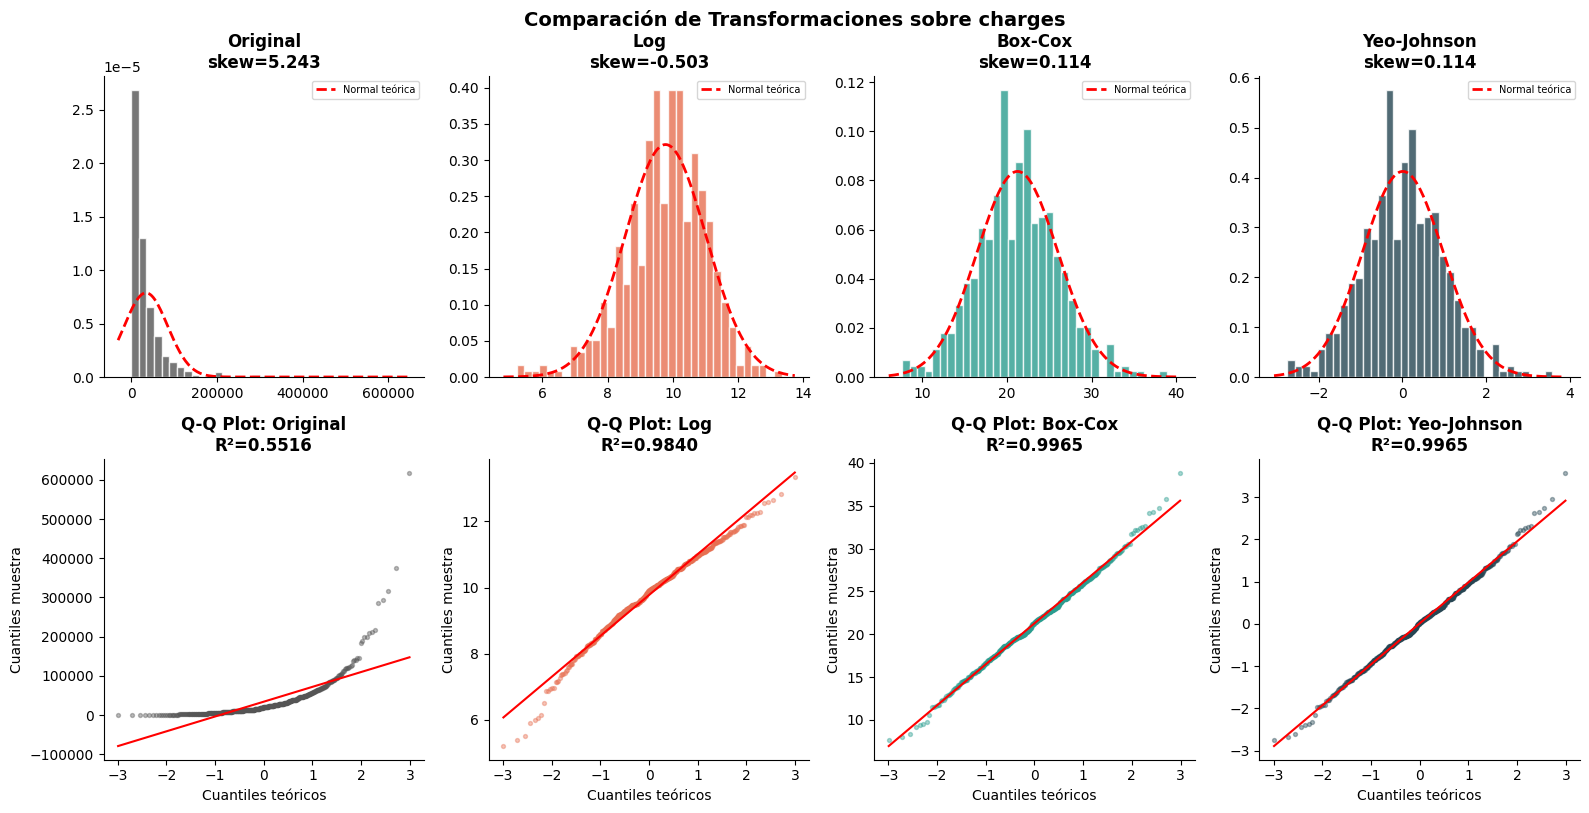

In [54]:
# Visualización: Q-Q plots + histogramas para charges
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
nombres_tr = list(transformaciones.keys())
colores_tr = ['#555555', '#E76F51', '#2A9D8F', '#264653']

for col, (nombre, data) in enumerate(transformaciones.items()):
    # Histograma con curva normal teórica
    ax_h = axes[0, col]
    ax_h.hist(data, bins=35, color=colores_tr[col], alpha=0.8, edgecolor='white', density=True)
    xmin, xmax = ax_h.get_xlim()
    x_norm = np.linspace(xmin, xmax, 200)
    ax_h.plot(x_norm, stats.norm.pdf(x_norm, np.mean(data), np.std(data)),
              'r--', linewidth=2, label='Normal teórica')
    ax_h.set_title(f'{nombre}\nskew={skew(data):.3f}', fontweight='bold')
    ax_h.legend(fontsize=7)

    # Q-Q plot
    ax_q = axes[1, col]
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')
    ax_q.scatter(osm, osr, alpha=0.4, s=8, color=colores_tr[col])
    ax_q.plot(osm, slope * np.array(osm) + intercept, 'r-', linewidth=1.5)
    ax_q.set_title(f'Q-Q Plot: {nombre}\nR²={r**2:.4f}', fontweight='bold')
    ax_q.set_xlabel('Cuantiles teóricos')
    ax_q.set_ylabel('Cuantiles muestra')

plt.tight_layout()
plt.suptitle('Comparación de Transformaciones sobre charges', fontsize=14, fontweight='bold', y=1.01)
plt.show()

In [ ]:
# Elección final + función de re-transformación
print("🏆 Transformación seleccionada para charges: LOGARÍTMICA")
print()
print("Justificación:")
print("  • La transformación Box Cox y Yeo-Johnson reducen en mayor medida el sesgo")
print("  • La transformación Box Cox y Yeo-Johnson cumplen la prueba de hipotesis")
print("  • La transformación Box Cox y Yeo-Johnson están más cerca de una distribución normal")
print()



🏆 Transformación seleccionada para charges: LOGARÍTMICA

Justificación:
  • La transformación Box Cox y Yeo-Johnson reducen en mayor medida el sesgo
  • La transformación Box Cox y Yeo-Johnson cumplen la prueba de hipotesis
  • La transformación Box Cox y Yeo-Johnson están más cerca de una distribución normal



### Accidentes Personales

In [87]:
siniestro = df_ap[df_ap.monto_pagado>0]['monto_pagado'].copy()

# 1. Transformación Logarítmica
charges_log = np.log(siniestro+1)

# 2. Box-Cox (solo valores positivos — perfecto para charges y bmi)
charges_boxcox, lambda_charges = stats.boxcox(siniestro+1)

# 3. Yeo-Johnson (acepta ceros y negativos — útil para cambios)
yj = PowerTransformer(method='yeo-johnson')
charges_yj = yj.fit_transform(siniestro.values.reshape(-1, 1)).ravel()

print(f"Lambdas estimadas por Box-Cox:")
print(f"  charges: λ = {lambda_charges:.4f} ")
print()
print(f"Lambda Yeo-Johnson para charges: {yj.lambdas_[0]:.4f}")

Lambdas estimadas por Box-Cox:
  charges: λ = 0.1239 

Lambda Yeo-Johnson para charges: 0.1239


In [88]:
# Test de normalidad: Shapiro-Wilk (muestra de 500 para mayor potencia)
np.random.seed(SEED)
muestra = np.random.choice(len(siniestro), 500, replace=False)

transformaciones = {
    'Original':   siniestro.values[muestra],
    'Log':        charges_log.values[muestra],
    'Box-Cox':    charges_boxcox[muestra],
    'Yeo-Johnson': charges_yj[muestra],
}

print("=" * 60)
print("TEST DE NORMALIDAD SHAPIRO-WILK (n=500, charges)")
print("H₀: la variable sigue distribución normal")
print("=" * 60)
print(f"{'Transformación':<15} {'Skewness':>10} {'W-stat':>10} {'p-valor':>12} {'Normal?':>10}")
print("-" * 60)
for nombre, data in transformaciones.items():
    sk = skew(data)
    w, p = shapiro(data)
    normal = "✅ Sí" if p > 0.05 else "❌ No"
    print(f"{nombre:<15} {sk:>10.4f} {w:>10.4f} {p:>12.6f} {normal:>10}")

TEST DE NORMALIDAD SHAPIRO-WILK (n=500, charges)
H₀: la variable sigue distribución normal
Transformación    Skewness     W-stat      p-valor    Normal?
------------------------------------------------------------
Original            8.3657     0.3882     0.000000       ❌ No
Log                -0.7568     0.9653     0.000000       ❌ No
Box-Cox             0.0112     0.9886     0.000639       ❌ No
Yeo-Johnson         0.0112     0.9886     0.000639       ❌ No


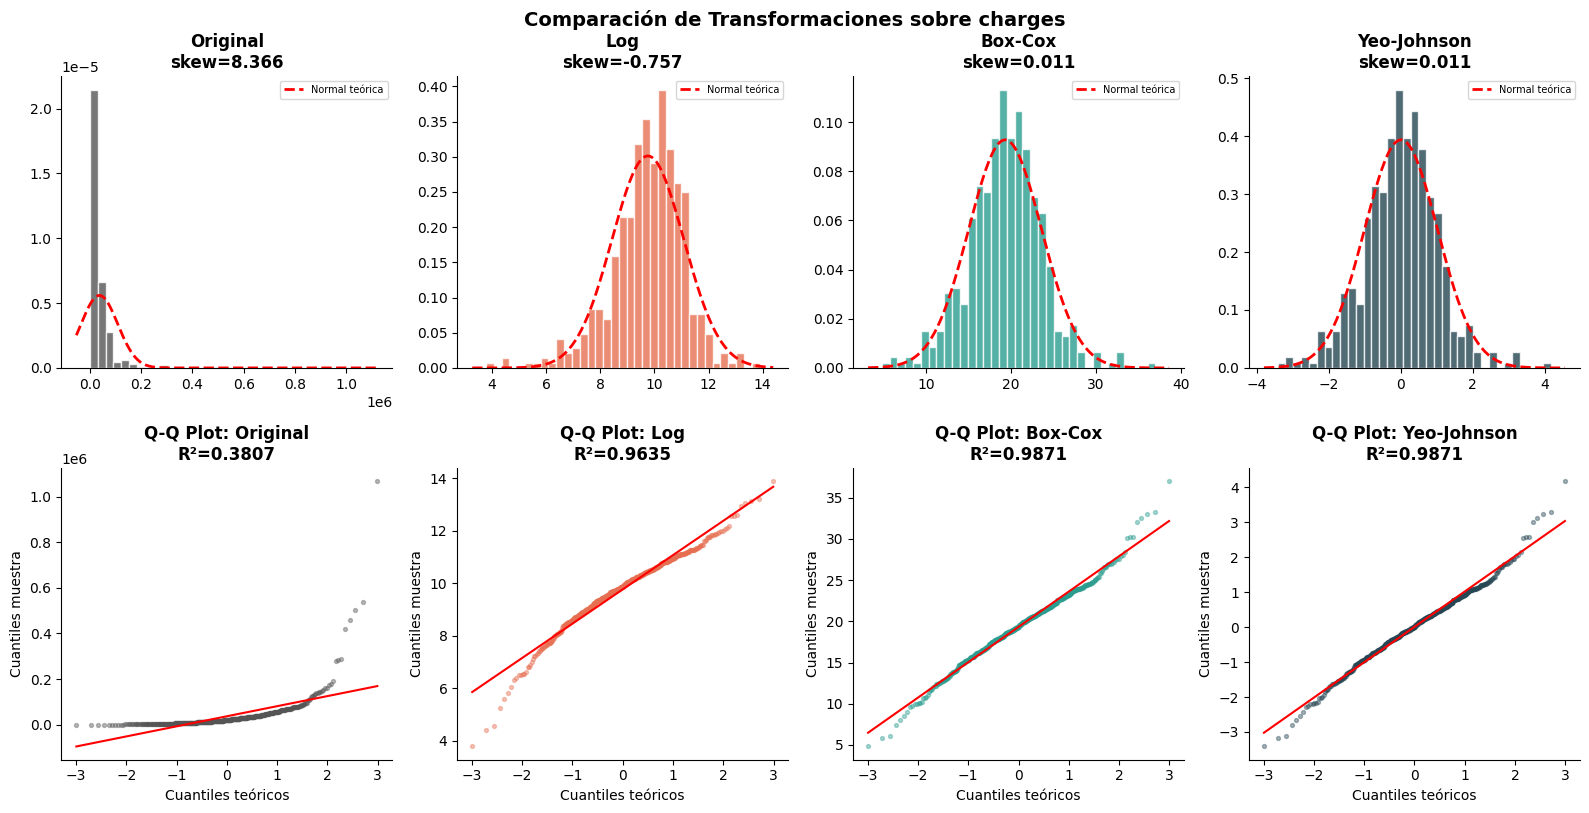

In [89]:
# Visualización: Q-Q plots + histogramas para charges
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
nombres_tr = list(transformaciones.keys())
colores_tr = ['#555555', '#E76F51', '#2A9D8F', '#264653']

for col, (nombre, data) in enumerate(transformaciones.items()):
    # Histograma con curva normal teórica
    ax_h = axes[0, col]
    ax_h.hist(data, bins=35, color=colores_tr[col], alpha=0.8, edgecolor='white', density=True)
    xmin, xmax = ax_h.get_xlim()
    x_norm = np.linspace(xmin, xmax, 200)
    ax_h.plot(x_norm, stats.norm.pdf(x_norm, np.mean(data), np.std(data)),
              'r--', linewidth=2, label='Normal teórica')
    ax_h.set_title(f'{nombre}\nskew={skew(data):.3f}', fontweight='bold')
    ax_h.legend(fontsize=7)

    # Q-Q plot
    ax_q = axes[1, col]
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')
    ax_q.scatter(osm, osr, alpha=0.4, s=8, color=colores_tr[col])
    ax_q.plot(osm, slope * np.array(osm) + intercept, 'r-', linewidth=1.5)
    ax_q.set_title(f'Q-Q Plot: {nombre}\nR²={r**2:.4f}', fontweight='bold')
    ax_q.set_xlabel('Cuantiles teóricos')
    ax_q.set_ylabel('Cuantiles muestra')

plt.tight_layout()
plt.suptitle('Comparación de Transformaciones sobre charges', fontsize=14, fontweight='bold', y=1.01)
plt.show()

In [ ]:
# Elección final + función de re-transformación
print("🏆 Transformación seleccionada para charges: LOGARÍTMICA")
print()
print("Justificación:")
print("  • La transformación Box Cox y Yeo-Johnson reducen en mayor medida el sesgo")
print("  • La transformación Box Cox y Yeo-Johnson están más cerca de una distribución normal")
print()

---
## 3. 🏷️ Codifica las variables que consideres necesario. Explica por qué consideraste esas variables y que tipo de codificación aplicaste.

### Gastos Médicos

El dataset tiene 3 variables categóricas:
- `sexo`: binaria (2 categorías) → Label Encoding
- `edad_mayor_65`: binaria (2 categorías) → Label Encoding / Dummy
- `region`: 15 categorías nominales sin orden → One-Hot Encoding

Estas variables son importantes a codificar ya que la edad y sexo están altamente correlacionadas al riesgo de un seguro de gastos medicos, mientras que la región también es dependiente del costo hospitalario.

In [66]:
df['edad_mayor_65'] = np.where(df.edad>65, "si","no")

In [ ]:
df_enc = df.copy()

# 1. Label Encoding para variables binarias
le = LabelEncoder()
df_enc['sex_num']    = le.fit_transform(df_enc['sexo'])        # female=0, male=1
df_enc['edad_mayor_65_num'] = (df_enc['edad_mayor_65'] == 'si').astype(int) 

print("✅ Label Encoding aplicado:")
print(f"   sexo:    F→{df_enc[df_enc.sexo=='F'].sex_num.iloc[0]}, M→{df_enc[df_enc.sexo=='M'].sex_num.iloc[0]}")
print(f"   edad_mayor_65: no→{df_enc[df_enc.edad_mayor_65=='no'].edad_mayor_65_num.iloc[0]},    si→{df_enc[df_enc.edad_mayor_65=='si'].edad_mayor_65_num.iloc[0]}")
print()

# 2. One-Hot Encoding para region (4 categorías, baja cardinalidad)
ohe = OneHotEncoder(drop='first', sparse_output=False, dtype=int)
region_ohe = ohe.fit_transform(df_enc[['region']])
region_cols = ohe.get_feature_names_out(['region'])
df_enc[region_cols] = region_ohe

print("✅ One-Hot Encoding para region:")
print(f"   Categoría base (eliminada): Baja California")
print(f"   Columnas creadas: {list(region_cols)}")
print()
print("Muestra de la codificación:")
display(df_enc[['region'] + list(region_cols)].drop_duplicates().sort_values('region'))

✅ Label Encoding aplicado:
   sexo:    F→0, M→1
   edad_mayor_65: no→0,    si→1

✅ One-Hot Encoding para region:
   Categoría base (eliminada): southeast
   Columnas creadas: ['region_CDMX', 'region_Chihuahua', 'region_Coahuila', 'region_Estado de Mexico', 'region_Guanajuato', 'region_Jalisco', 'region_Michoacan', 'region_Nuevo Leon', 'region_Puebla', 'region_Queretaro', 'region_Sonora', 'region_Tamaulipas', 'region_Veracruz', 'region_Yucatan']

Muestra de la codificación:


,region,region_CDMX,region_Chihuahua,region_Coahuila,region_Estado de Mexico,region_Guanajuato,region_Jalisco,region_Michoacan,region_Nuevo Leon,region_Puebla,region_Queretaro,region_Sonora,region_Tamaulipas,region_Veracruz,region_Yucatan
20,Baja California,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,CDMX,1,0,0,0,0,0,0,0,0,0,0,0,0,0
0,Chihuahua,0,1,0,0,0,0,0,0,0,0,0,0,0,0
42,Coahuila,0,0,1,0,0,0,0,0,0,0,0,0,0,0
4,Estado de Mexico,0,0,0,1,0,0,0,0,0,0,0,0,0,0
6,Guanajuato,0,0,0,0,1,0,0,0,0,0,0,0,0,0
3,Jalisco,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2,Michoacan,0,0,0,0,0,0,1,0,0,0,0,0,0,0
181,Nuevo Leon,0,0,0,0,0,0,0,1,0,0,0,0,0,0
19,Puebla,0,0,0,0,0,0,0,0,1,0,0,0,0,0


### Accidentes Personales

El dataset tiene 3 variables categóricas:
- `sexo`: binaria (2 categorías) → Label Encoding
- `edad_mayor_65`: binaria (2 categorías) → Label Encoding / Dummy
- `region`: 15 categorías nominales sin orden → One-Hot Encoding

Estas variables son importantes a codificar ya que la edad y sexo están altamente correlacionadas al riesgo de un seguro de accidentes personales, mientras que la región también es dependiente del costo hospitalario.

In [90]:
df_ap['edad_mayor_65'] = np.where(df_ap.edad>65, "si","no")

In [91]:
df_enc_ap = df_ap.copy()

# 1. Label Encoding para variables binarias
le = LabelEncoder()
df_enc_ap['sex_num']    = le.fit_transform(df_enc_ap['sexo'])        # female=0, male=1
df_enc_ap['edad_mayor_65_num'] = (df_enc_ap['edad_mayor_65'] == 'si').astype(int) 

print("✅ Label Encoding aplicado:")
print(f"   sexo:    F→{df_enc_ap[df_enc_ap.sexo=='F'].sex_num.iloc[0]}, M→{df_enc_ap[df_enc_ap.sexo=='M'].sex_num.iloc[0]}")
print(f"   edad_mayor_65: no→{df_enc_ap[df_enc_ap.edad_mayor_65=='no'].edad_mayor_65_num.iloc[0]},    si→{df_enc_ap[df_enc_ap.edad_mayor_65=='si'].edad_mayor_65_num.iloc[0]}")
print()

# 2. One-Hot Encoding para region (4 categorías, baja cardinalidad)
ohe = OneHotEncoder(drop='first', sparse_output=False, dtype=int)
region_ohe = ohe.fit_transform(df_enc_ap[['region']])
region_cols = ohe.get_feature_names_out(['region'])
df_enc_ap[region_cols] = region_ohe

print("✅ One-Hot Encoding para region:")
print(f"   Categoría base (eliminada): Baja California")
print(f"   Columnas creadas: {list(region_cols)}")
print()
print("Muestra de la codificación:")
display(df_enc[['region'] + list(region_cols)].drop_duplicates().sort_values('region'))

✅ Label Encoding aplicado:
   sexo:    F→0, M→1
   edad_mayor_65: no→0,    si→1

✅ One-Hot Encoding para region:
   Categoría base (eliminada): Baja California
   Columnas creadas: ['region_CDMX', 'region_Chihuahua', 'region_Coahuila', 'region_Estado de Mexico', 'region_Guanajuato', 'region_Jalisco', 'region_Michoacan', 'region_Nuevo Leon', 'region_Puebla', 'region_Queretaro', 'region_Sonora', 'region_Tamaulipas', 'region_Veracruz', 'region_Yucatan']

Muestra de la codificación:


,region,region_CDMX,region_Chihuahua,region_Coahuila,region_Estado de Mexico,region_Guanajuato,region_Jalisco,region_Michoacan,region_Nuevo Leon,region_Puebla,region_Queretaro,region_Sonora,region_Tamaulipas,region_Veracruz,region_Yucatan
20,Baja California,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,CDMX,1,0,0,0,0,0,0,0,0,0,0,0,0,0
0,Chihuahua,0,1,0,0,0,0,0,0,0,0,0,0,0,0
42,Coahuila,0,0,1,0,0,0,0,0,0,0,0,0,0,0
4,Estado de Mexico,0,0,0,1,0,0,0,0,0,0,0,0,0,0
6,Guanajuato,0,0,0,0,1,0,0,0,0,0,0,0,0,0
3,Jalisco,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2,Michoacan,0,0,0,0,0,0,1,0,0,0,0,0,0,0
181,Nuevo Leon,0,0,0,0,0,0,0,1,0,0,0,0,0,0
19,Puebla,0,0,0,0,0,0,0,0,1,0,0,0,0,0


---
## 7. 🧮 Calcula las siguientes variables derivadas: mayor de 65 años, Siniestros altos (se definen como los montos pagados mayores a $25,000 en accidentes personales y mayores a $200,000 en gastos médicos). ¿Cuántos siniestros cumplen estas características y qué % del total de siniestros representan?


### Gastos Médicos

In [73]:
df['ID_edad_mayor_65'] = (df.edad>65).astype(int)

df['Siniestros_altos'] = (df.monto_pagado>200000).astype(int)

print(f'Siniestros con edad mayor a 65: {df[df.n_siniestros>0].ID_edad_mayor_65.sum()}')
print(f'% Siniestros con edad mayor a 65: {df[df.n_siniestros>0].ID_edad_mayor_65.sum()/df.n_siniestros.sum():.2%}')
print()

print(f'Siniestros mayores a 200 mil: {df[df.n_siniestros>0].Siniestros_altos.sum()}')
print(f'% Siniestros mayores a 200 mil: {df[df.n_siniestros>0].Siniestros_altos.sum()/df.n_siniestros.sum():.2%}')

Siniestros con edad mayor a 65: 41
% Siniestros con edad mayor a 65: 0.50%

Siniestros mayores a 200 mil: 45
% Siniestros mayores a 200 mil: 0.55%


### Accidentes Personales

In [ ]:
df_ap['ID_edad_mayor_65'] = (df_ap.edad>65).astype(int)

df_ap['Siniestros_altos'] = (df_ap.monto_pagado>25000).astype(int)

print(f'Siniestros con edad mayor a 65: {df_ap[df_ap.n_siniestros>0].ID_edad_mayor_65.sum()}')
print(f'% Siniestros con edad mayor a 65: {df_ap[df_ap.n_siniestros>0].ID_edad_mayor_65.sum()/df_ap.n_siniestros.sum():.2%}')
print()

print(f'Siniestros mayores a 25 mil: {df_ap[df_ap.n_siniestros>0].Siniestros_altos.sum()}')
print(f'% Siniestros mayores a 25 mil: {df_ap[df_ap.n_siniestros>0].Siniestros_altos.sum()/df_ap.n_siniestros.sum():.2%}')

Siniestros con edad mayor a 65: 12
% Siniestros con edad mayor a 65: 0.65%

Siniestros mayores a 200 mil: 263
% Siniestros mayores a 200 mil: 14.35%


## 8.	Calcula la media del siniestro por sexo, año de inicio de vigencia y plan

### Gastos Médicos

In [75]:
print('Siniestro medio por sexo:')
media_siniestros_sex = df.groupby(['sexo'])['monto_pagado'].mean().reset_index()
media_siniestros_sex.rename(columns={'monto_siniestro': 'media_siniestro'}, inplace=True)
print(media_siniestros_sex)

print()
print('Siniestro medio por año de inicio de vigencia:')
media_siniestros_aniovig = df.groupby(['anio_ini_vig'])['monto_pagado'].mean().reset_index()
media_siniestros_aniovig.rename(columns={'monto_siniestro': 'media_siniestro'}, inplace=True)
print(media_siniestros_aniovig)

print()
print('Siniestro medio por tipo de plan:')
media_siniestros_plan = df.groupby(['plan'])['monto_pagado'].mean().reset_index()
media_siniestros_plan.rename(columns={'monto_siniestro': 'media_siniestro'}, inplace=True)
print(media_siniestros_plan)

Siniestro medio por sexo:
  sexo  monto_pagado
0    F   4478.875937
1    M   4123.112830

Siniestro medio por año de inicio de vigencia:
   anio_ini_vig  monto_pagado
0          2019   4012.865439
1          2020   4431.064917
2          2021   4265.351355
3          2022   4584.198036
4          2023   4594.036147
5          2024   3917.896155

Siniestro medio por tipo de plan:
           plan  monto_pagado
0      10 anios           NaN
1      20 anios           NaN
2        Amplia           NaN
3   Amplia Plus           NaN
4        Basico   4249.157698
5         Elite   4256.672634
6      Familiar           NaN
7    Individual           NaN
8    Permanente           NaN
9          Plus   4469.137127
10      Premium   4227.268791
11        RC+LT           NaN


### Accidentes personales

In [93]:
print('Siniestro medio por sexo:')
media_siniestros_sex = df_ap.groupby(['sexo'])['monto_pagado'].mean().reset_index()
media_siniestros_sex.rename(columns={'monto_siniestro': 'media_siniestro'}, inplace=True)
print(media_siniestros_sex)

print()
print('Siniestro medio por año de inicio de vigencia:')
media_siniestros_aniovig = df_ap.groupby(['anio_ini_vig'])['monto_pagado'].mean().reset_index()
media_siniestros_aniovig.rename(columns={'monto_siniestro': 'media_siniestro'}, inplace=True)
print(media_siniestros_aniovig)

print()
print('Siniestro medio por tipo de plan:')
media_siniestros_plan = df_ap.groupby(['plan'])['monto_pagado'].mean().reset_index()
media_siniestros_plan.rename(columns={'monto_siniestro': 'media_siniestro'}, inplace=True)
print(media_siniestros_plan)

Siniestro medio por sexo:
  sexo  monto_pagado
0    F   4862.073048
1    M   3698.084969

Siniestro medio por año de inicio de vigencia:
   anio_ini_vig  monto_pagado
0          2019   3585.222137
1          2020   5008.200242
2          2021   4860.284661
3          2022   4472.064647
4          2023   3686.616685
5          2024   4104.946951

Siniestro medio por tipo de plan:
           plan  monto_pagado
0      10 anios           NaN
1      20 anios           NaN
2        Amplia           NaN
3   Amplia Plus           NaN
4        Basico           NaN
5         Elite           NaN
6      Familiar   4203.663558
7    Individual   4367.649984
8    Permanente           NaN
9          Plus           NaN
10      Premium           NaN
11        RC+LT           NaN
